# Оптимизация нейронных сетей.

> Узнаем как устроена оптимизация нейронных сетей. Оптимизация в `PyTorch`.

## План ноутбука

1. Высокоуровневое API для обучение нейросетей в `PyTorch`
2. Обучение первой нейросети в `PyTorch`

## Высокоуровневое API для обучение нейросетей в `PyTorch`

In [1]:
import torch
import torch.nn as nn

%cd /home/jovyan/bspanfilov/dl_seminars/02

/home/jovyan/bspanfilov/dl_seminars/02


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


### Забыл показать на прошлом семе

In [2]:
a = torch.rand(5, requires_grad=True)
b = torch.rand(5, requires_grad=True)

In [3]:
a, b

(tensor([0.6453, 0.5499, 0.2604, 0.5071, 0.4140], requires_grad=True),
 tensor([0.9031, 0.1052, 0.7656, 0.2017, 0.9916], requires_grad=True))

In [4]:
loss = (a - b).sum()

In [5]:
loss.backward()

In [6]:
a.grad

tensor([1., 1., 1., 1., 1.])

In [7]:
loss.backward()

In [8]:
a.grad

tensor([2., 2., 2., 2., 2.])

### Создание объекта нейросети

[nn.Sequential](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html)

In [9]:
net = nn.Sequential(
    nn.Linear(700, 500),
    nn.ReLU(),
    nn.Linear(500, 200),
    nn.ReLU(),
    nn.Linear(200, 10)
)

In [10]:
net

Sequential(
  (0): Linear(in_features=700, out_features=500, bias=True)
  (1): ReLU()
  (2): Linear(in_features=500, out_features=200, bias=True)
  (3): ReLU()
  (4): Linear(in_features=200, out_features=10, bias=True)
)

In [11]:
net[1]

ReLU()

In [12]:
input = torch.randn((5, 700))

In [13]:
net(input)

tensor([[ 0.0973, -0.1324, -0.2369,  0.1566, -0.2252, -0.0337,  0.0003, -0.2099,
          0.1668,  0.1150],
        [ 0.1542,  0.0287, -0.1210,  0.1060, -0.1707, -0.0335,  0.0668, -0.1356,
          0.2129,  0.0948],
        [ 0.1218,  0.0085, -0.0277,  0.2208, -0.1916, -0.0543, -0.0506, -0.1267,
          0.1393,  0.0009],
        [ 0.1147, -0.0551, -0.0620,  0.1093, -0.0404, -0.1008, -0.0210, -0.0983,
          0.0943,  0.0006],
        [ 0.2485, -0.1189, -0.2041,  0.1156, -0.2210, -0.1156,  0.0586, -0.1525,
          0.0808, -0.1509]], grad_fn=<AddmmBackward0>)

nn.Sequential + OrderedDict

In [14]:
from collections import OrderedDict

net = nn.Sequential(
    OrderedDict(
        [
            ('linear1', nn.Linear(700, 500)),
            ('relu1', nn.ReLU()),
            ('linear2', nn.Linear(500, 200)),
            ('relu2', nn.ReLU()),
            ('linear3', nn.Linear(200, 10))
        ]
    )
)

In [15]:
net.linear1.weight

Parameter containing:
tensor([[-0.0229,  0.0201, -0.0375,  ...,  0.0106, -0.0120,  0.0177],
        [ 0.0179, -0.0230, -0.0148,  ...,  0.0295,  0.0108,  0.0151],
        [ 0.0286,  0.0286,  0.0234,  ..., -0.0312,  0.0044,  0.0054],
        ...,
        [ 0.0214, -0.0172, -0.0032,  ..., -0.0058,  0.0032,  0.0149],
        [-0.0294, -0.0370, -0.0265,  ...,  0.0167, -0.0346, -0.0012],
        [-0.0134,  0.0353,  0.0191,  ..., -0.0042,  0.0364,  0.0144]],
       requires_grad=True)

In [16]:
net

Sequential(
  (linear1): Linear(in_features=700, out_features=500, bias=True)
  (relu1): ReLU()
  (linear2): Linear(in_features=500, out_features=200, bias=True)
  (relu2): ReLU()
  (linear3): Linear(in_features=200, out_features=10, bias=True)
)

In [17]:
input_tensor = torch.rand(10, 700)

net(input_tensor).shape

torch.Size([10, 10])

Унаследоваться от [nn.Module](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html) и определить методы `__init__`и `forward`.

* позволяет добавлять кастомный forward
* позволяет удобно управлять моделью (to.(device), .eval(), .train(), .parameters())
* позволяет сделать модель частью экосистемы пайторч. (Совместимость с уже написанными оптимизаторами, jit-компиляцией, DDP и другое)

In [18]:
class CustomTaskNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear1 = nn.Linear(700, 500)
        self.linear2 = nn.Linear(500, 200)
        self.linear3 = nn.Linear(200, 10)

        self.activation1 = nn.ReLU()
        self.activation2 = nn.Sigmoid()

    def forward(self, x):
        # x.shape = (10, 700)
        output = self.activation1(self.linear1(x)) # (10, 500)
        output = self.activation2(self.linear2(output)) # (10, 200)
        output = self.linear3(output) # (10, 10)

        return output

In [19]:
net = CustomTaskNetwork()

net(input_tensor).shape

torch.Size([10, 10])

In [20]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(net)

452710

In [21]:
700 * 500 + 500 + 500 * 200 + 200 + 200 * 10 + 10

452710

[nn.ModuleList](https://docs.pytorch.org/docs/stable/generated/torch.nn.ModuleList.html#torch.nn.ModuleList)

In [22]:
class MyModule(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.linears = nn.ModuleList([nn.Linear(10, 10) for i in range(10)])
        self.ReLU = nn.ReLU()

    def forward(self, x):
        for i, l in enumerate(self.linears):
            x = self.ReLU(self.linears[i // 2](x) + l(x))
        return x

net = MyModule()


In [23]:
net.linears[0].weight.requires_grad

True

In [24]:
net.requires_grad_(False)
net.linears[0].weight.requires_grad

False

Как не заработает:

In [25]:
class MyModule(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.linears = [nn.Linear(10, 10) for i in range(10)]

    def forward(self, x):
        for i, l in enumerate(self.linears):
            x = self.linears[i // 2](x) + l(x)
        return x

net = MyModule()

In [26]:
net.linears[0].weight.requires_grad

True

In [27]:
net.requires_grad_(False)
net.linears[0].weight.requires_grad

True

### Управление объектом нейросети

In [28]:
class CustomNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear1 = nn.Linear(700, 500)
        self.linear2 = nn.Linear(500, 200)
        self.linear3 = nn.Linear(200, 10)

        self.activation1 = nn.ReLU()
        self.activation2 = nn.Sigmoid()

    def forward(self, x):
        output = self.activation1(self.linear1(x))
        output = self.activation2(self.linear2(output))
        output = self.linear3(output)

        return output

In [29]:
net = CustomNetwork()

In [30]:
net

CustomNetwork(
  (linear1): Linear(in_features=700, out_features=500, bias=True)
  (linear2): Linear(in_features=500, out_features=200, bias=True)
  (linear3): Linear(in_features=200, out_features=10, bias=True)
  (activation1): ReLU()
  (activation2): Sigmoid()
)

In [31]:
class WrapperNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = CustomNetwork()
    
    def forward(self, x):
        return self.net(x)

In [32]:
net = WrapperNetwork()

In [33]:
net

WrapperNetwork(
  (net): CustomNetwork(
    (linear1): Linear(in_features=700, out_features=500, bias=True)
    (linear2): Linear(in_features=500, out_features=200, bias=True)
    (linear3): Linear(in_features=200, out_features=10, bias=True)
    (activation1): ReLU()
    (activation2): Sigmoid()
  )
)

In [34]:
net.train()

net.eval()  # понимать разницу с net.requires_grad_(False)

net.requires_grad_(False)

WrapperNetwork(
  (net): CustomNetwork(
    (linear1): Linear(in_features=700, out_features=500, bias=True)
    (linear2): Linear(in_features=500, out_features=200, bias=True)
    (linear3): Linear(in_features=200, out_features=10, bias=True)
    (activation1): ReLU()
    (activation2): Sigmoid()
  )
)

In [35]:
for k, v in net.named_parameters():
    print(k, v.shape)

net.linear1.weight torch.Size([500, 700])
net.linear1.bias torch.Size([500])
net.linear2.weight torch.Size([200, 500])
net.linear2.bias torch.Size([200])
net.linear3.weight torch.Size([10, 200])
net.linear3.bias torch.Size([10])


In [36]:
n = next(net.parameters())
n

Parameter containing:
tensor([[-0.0318,  0.0176,  0.0245,  ..., -0.0174,  0.0200, -0.0297],
        [-0.0060, -0.0306, -0.0175,  ...,  0.0220,  0.0360,  0.0322],
        [-0.0114,  0.0189, -0.0193,  ..., -0.0280, -0.0065,  0.0155],
        ...,
        [-0.0123, -0.0147, -0.0073,  ...,  0.0042,  0.0058,  0.0142],
        [-0.0354,  0.0198, -0.0371,  ..., -0.0153,  0.0046,  0.0175],
        [-0.0276,  0.0339, -0.0170,  ...,  0.0008, -0.0226,  0.0059]])

Сериализация и сохранение модели.

Правильный способ

In [37]:
torch.save(net.state_dict(), "weights.pth")

In [38]:
weights = torch.load("weights.pth", map_location="cpu")
net.load_state_dict(weights)
net.state_dict()

/tmp/ipykernel_43950/250187160.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load("weights.pth", map_location="cpu")


OrderedDict([('net.linear1.weight',
              tensor([[-0.0318,  0.0176,  0.0245,  ..., -0.0174,  0.0200, -0.0297],
                      [-0.0060, -0.0306, -0.0175,  ...,  0.0220,  0.0360,  0.0322],
                      [-0.0114,  0.0189, -0.0193,  ..., -0.0280, -0.0065,  0.0155],
                      ...,
                      [-0.0123, -0.0147, -0.0073,  ...,  0.0042,  0.0058,  0.0142],
                      [-0.0354,  0.0198, -0.0371,  ..., -0.0153,  0.0046,  0.0175],
                      [-0.0276,  0.0339, -0.0170,  ...,  0.0008, -0.0226,  0.0059]])),
             ('net.linear1.bias',
              tensor([-1.0175e-02,  1.2001e-02,  1.5481e-02, -2.0902e-02,  2.5201e-04,
                       2.1328e-03,  1.2045e-02,  3.4957e-02, -3.0653e-03,  1.1330e-02,
                       1.7089e-02, -1.1099e-02,  3.5068e-02, -3.2642e-02, -3.3261e-02,
                      -3.1021e-02, -8.4575e-03,  3.4079e-02, -2.7456e-03,  2.2478e-02,
                       9.9561e-03,  7.6941e-04, 

Если мы хотим проинициализировать сетку какими-то весами из словаря, то важно чтобы названия и размеры параметров в передаваемом словаре совпадали с названиями и размерами параметров сетки

In [39]:
net.load_state_dict({'linear5.weight': torch.rand((1, 2, 3))})

RuntimeError: Error(s) in loading state_dict for WrapperNetwork:
	Missing key(s) in state_dict: "net.linear1.weight", "net.linear1.bias", "net.linear2.weight", "net.linear2.bias", "net.linear3.weight", "net.linear3.bias". 
	Unexpected key(s) in state_dict: "linear5.weight". 

Неправильный способ

In [48]:
torch.save(net, "net.pth")
net_loaded = torch.load("net.pth")

/tmp/ipykernel_43950/3456005737.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net_loaded = torch.load("net.pth")


Про torch.load()

In [49]:
a = torch.rand((10000, 100000))

In [50]:
a.device

device(type='cpu')

In [51]:
a_cuda = a.to('cuda:0')
a_cuda.device


device(type='cuda', index=0)

In [52]:
torch.save(a_cuda, "a_cuda.pt")

In [53]:
%%timeit
torch.load("a_cuda.pt")

<magic-timeit>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


1.92 s ± 53.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [54]:
%%timeit
torch.load("a_cuda.pt", map_location="cuda:0")

<magic-timeit>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


1.94 s ± 28.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [55]:
%%timeit
torch.load("a_cuda.pt", map_location="cpu")

<magic-timeit>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


1.71 s ± 9.47 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Вывод: пути диск -> gpu нет, всегда перемещения происходят через cpu.

### Оптимизаторы

[torch.optim.SGD](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html)

[torch.optim.ADAM](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html)

In [56]:
net = CustomNetwork()
optimizer = torch.optim.Adam(net.parameters(), lr=0.0001)

In [57]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)

In [58]:
optimizer = torch.optim.SGD(
    [
        {'params': net.linear1.parameters()},
        {'params': net.linear2.parameters(), 'lr': 1e-3}
    ],
    lr=1e-2,
    momentum=0.9
)

In [59]:
optimizer.step()

In [60]:
optimizer.zero_grad()  # так, а не model.zero_grad(), потому что можем хотеть оптимизировать не всю модель

In [61]:
checkpoint = {
    'epoch': 23,
    'model': net,
    'optimizer': optimizer
    }
torch.save(checkpoint, 'checkpoint.pth')

In [62]:
checkpoint = torch.load('checkpoint.pth', weights_only=False)
epoch = checkpoint['epoch']
model = checkpoint['model']
optimizer = checkpoint['optimizer']

### Функции потерь

[nn.L1Loss](https://docs.pytorch.org/docs/stable/generated/torch.nn.L1Loss.html)

[nn.MSELoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)

[nn.CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

In [63]:
loss = nn.MSELoss()

In [64]:
net = nn.Sequential(
    nn.Linear(700, 500),
    nn.ReLU(),
    nn.Linear(500, 200),
    nn.ReLU(),
    nn.Linear(200, 10)
)

In [65]:
input_tensor = torch.randn(10, 700, device="cuda")
net = net.to("cuda")
input = net(input_tensor)
target = torch.randn(10, 10, device="cuda")

output = loss(input, target)

print(output)

output.backward()

tensor(1.0702, device='cuda:0', grad_fn=<MseLossBackward0>)


In [66]:
net[0].weight.grad

tensor([[ 1.7959e-03, -1.3678e-03,  2.3323e-03,  ...,  2.3536e-03,
         -1.6539e-03, -7.3846e-04],
        [-2.3956e-03,  2.3686e-03, -2.4882e-03,  ..., -3.4935e-03,
          2.6799e-03,  4.5030e-04],
        [ 1.5008e-03, -1.7035e-03,  1.7123e-03,  ..., -9.1447e-04,
         -1.9113e-04,  1.8289e-03],
        ...,
        [-1.3161e-04,  1.7897e-03, -6.4083e-04,  ...,  1.2867e-03,
         -8.2664e-05,  5.6320e-04],
        [ 1.6049e-03, -9.1854e-04, -1.0297e-03,  ...,  1.1946e-03,
         -1.5601e-03, -1.2033e-03],
        [ 9.9829e-04, -9.2035e-04, -1.1872e-04,  ...,  1.5407e-04,
         -4.3687e-04,  8.3146e-05]], device='cuda:0')

### Датасеты и даталоадеры

#### Датасет

In [67]:
from torch.utils.data import Dataset

In [68]:
n_features = 2
n_objects = 300

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

In [69]:
w_true = torch.randn(n_features)

X = (torch.rand(n_objects, n_features) - 0.5) * 10
X *= (torch.arange(n_features) * 2 + 1)
Y = (X @ w_true + torch.randn(n_objects)).unsqueeze(1)

In [70]:
X.shape, Y.shape

(torch.Size([300, 2]), torch.Size([300, 1]))

In [71]:
# надо отнаследоваться от Dataset и определить методы __init__, __len__ и __getitem__

class CustomDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, item):
        return self.X[item], self.Y[item], "123"

In [72]:
dataset = CustomDataset(X, Y)

In [73]:
dataset[7]

(tensor([-2.3342,  3.8235]), tensor([0.3727]), '123')

In [74]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor, Compose, Lambda

dataset = MNIST("./MNIST", transform=Compose([ToTensor(), Lambda(lambda x: torch.flatten(x))]), download=True)
len(dataset)

60000

In [75]:
len(dataset[0]), dataset[0][0].shape, dataset[0][1]  # картинка + лейбл

(2, torch.Size([784]), 5)

In [76]:
28 * 28

784

#### Даталоадер

[torch.utils.data.DataLoader](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader)

In [77]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=2)
next(iter(loader))

[tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([5, 0])]

In [78]:
loader = DataLoader(dataset, batch_size=2, shuffle=True)
next(iter(loader))

[tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([1, 4])]

collate_fn

In [79]:
class CustomDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, item):
        return {"input": self.X[item], "target": self.Y[item], "meta_info": {"path": "hahaha", "link": "eheheh"}}

In [80]:
dataset = CustomDataset(X, Y)
dataset[0]

{'input': tensor([-1.0955,  3.0269]),
 'target': tensor([0.4938]),
 'meta_info': {'path': 'hahaha', 'link': 'eheheh'}}

In [81]:
loader = DataLoader(dataset, batch_size=2)
next(iter(loader))

{'input': tensor([[-1.0955,  3.0269],
         [-2.4343,  8.8092]]),
 'target': tensor([[0.4938],
         [0.6791]]),
 'meta_info': {'path': ['hahaha', 'hahaha'], 'link': ['eheheh', 'eheheh']}}

In [82]:
def collate_fn(batch):
    """
    batch: list of outputs getitem
    """
    input = torch.zeros(len(batch), *batch[0]["input"].shape)
    target = torch.zeros(len(batch), 1)

    for i in range(len(batch)):
        input[i] = batch[i]["input"]
        target[i] = batch[i]["target"]

    # other stuff with meta info ...
    
    return {"input": input, "target": target}

In [83]:
loader = DataLoader(dataset, batch_size=2, collate_fn=collate_fn)
next(iter(loader))

{'input': tensor([[-1.0955,  3.0269],
         [-2.4343,  8.8092]]),
 'target': tensor([[0.4938],
         [0.6791]])}

### Общая структура обучения модели

Модель

In [84]:
class MLP(nn.Module):
    def __init__(self, hidden_size=100):
        super().__init__()

        self.linear1 = nn.Linear(784, hidden_size)
        self.linear2 = nn.Linear(hidden_size, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        # (batch_size, 1, 28, 28)
        x = torch.flatten(x, start_dim=1)
        # (batch_size, 784)
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        
        return x

model = MLP().to("cuda")

Оптимизатор

In [85]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

Данные

In [86]:
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

train_set = MNIST('./MNIST', transform=ToTensor(), train=True, download=True)
val_set = MNIST('./MNIST', transform=ToTensor(), train=False, download=True)

In [87]:
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, drop_last=True)

In [88]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
device

'cuda:0'

In [89]:
from tqdm.notebook import tqdm
import torch.nn.functional as F

def test(model, loader):
    model.eval()  # отключает dropout, batchnorm и т.д., а не то же что и with torch.no_grad()

    correct, total = 0, 0

    for batch in loader:
        images, labels = batch[0], batch[1]
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            out = model(images)

        pred = torch.argmax(out, dim=1)

        total += len(pred)
        correct += (pred == labels).cpu().numpy().sum()

    return correct / total

In [90]:
def train(model, train_loader, val_loader, optimizer, epochs=10):
    train_acc, val_acc = [], []
    model.train()

    for epoch in tqdm(range(epochs), total=epochs):

        correct, total = 0, 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            out = model(images)
            loss = F.cross_entropy(out, labels)
            loss.backward()
            optimizer.step()

            pred = torch.argmax(out, dim=1)

            total += len(pred)
            correct += (pred == labels).detach().cpu().numpy().sum()

        train_acc.append(correct / total)
        val_acc.append(test(model, val_loader))
        torch.save(model.state_dict(), f"my_model_{epoch}.pth")

    return train_acc, val_acc

In [91]:
test(model, train_loader)

0.10935830662393162

In [92]:
train_acc, val_acc = train(model, train_loader, val_loader, optimizer, epochs=10)

  0%|          | 0/10 [00:00<?, ?it/s]

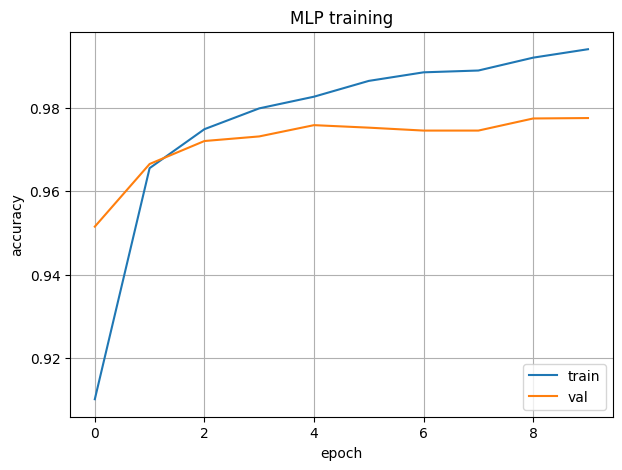

In [93]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(np.arange(10), train_acc, label='train')
plt.plot(np.arange(10), val_acc, label='val')

plt.grid()
plt.legend(loc='lower right')
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("MLP training")
plt.show()

Сохранение обученной модели

In [94]:
torch.save(model.state_dict(), "my_model.pth")

Применение обученной модели для получения предсказания

In [95]:
model.eval()

it = iter(val_loader)
elem = next(it)

with torch.no_grad():
    print(torch.argmax(model(elem[0][52].to("cuda"))))

tensor(5, device='cuda:0')


In [96]:
dataset = MNIST("./MNIST", train=False)
dataset[52][0]

и правда

Про pin_memory и num_workers в даталоадере

In [97]:
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, num_workers=4)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, drop_last=True, num_workers=4)

In [98]:
model = MLP().to("cuda")
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
train_acc, val_acc = train(model, train_loader, val_loader, optimizer, epochs=10)

  0%|          | 0/10 [00:00<?, ?it/s]

In [99]:
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, drop_last=True, num_workers=4, pin_memory=True)

In [100]:
model = MLP().to("cuda")
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
train_acc, val_acc = train(model, train_loader, val_loader, optimizer, epochs=10)

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
from torchvision.datasets import CIFAR10

train_set = CIFAR10('./CIFAR10', transform=ToTensor(), train=True, download=True)
val_set = CIFAR10('./CIFAR10', transform=ToTensor(), train=False, download=True)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, drop_last=True)

 ... (more hidden) ...


Extracting ./CIFAR10/cifar-10-python.tar.gz to ./CIFAR10
Files already downloaded and verified


In [ ]:
len(train_set), train_set[0][0].shape, 3 * 32 * 32, 

(50000, torch.Size([3, 32, 32]), 3072)

In [ ]:
class MLP(nn.Module):
    def __init__(self, hidden_size=100):
        super().__init__()

        self.linear1 = nn.Linear(3072, hidden_size)
        self.linear2 = nn.Linear(hidden_size, 10)

        self.relu = nn.ReLU()


    def forward(self, x):
        # (batch_size, 1, 28, 28)
        x = torch.flatten(x, start_dim=1)
        # (batch_size, 784)
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)

        
        return x

In [ ]:
model = MLP().to("cuda")
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
train_acc, val_acc = train(model, train_loader, val_loader, optimizer, epochs=10)

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, num_workers=4)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, drop_last=True, num_workers=4)

In [ ]:
model = MLP().to("cuda")
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
train_acc, val_acc = train(model, train_loader, val_loader, optimizer, epochs=10)

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, drop_last=True, num_workers=4, pin_memory=True)

In [ ]:
model = MLP().to("cuda")
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
train_acc, val_acc = train(model, train_loader, val_loader, optimizer, epochs=10)

  0%|          | 0/10 [00:00<?, ?it/s]